#ResNet-50 Style Residual Bottleneck Block and Grouped Convolution
#Objective:
 Master deep architectural scaling paradigms by constructing bottleneck
projection networks and multi-channel grouped/depthwise separable filters.
#Required Tech Stack:
 PyTorch, TorchVision, PyTorch Profiler.
#Task Description:
Students must build a custom ResNet-50 bottleneck block featuring
depthwise separable convolutions and learnable skip projection layers. They will run
PyTorch Profiler to analyze and optimize memory footprints, parameter counts, and
floating-point execution steps (FLOPs) under different channel scaling factors

Import Libraries

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.profiler import profile, ProfilerActivity

torch.manual_seed(42)

Create Sample Input

In [4]:
x = torch.randn(1,64,56,56)

print(x.shape)

torch.Size([1, 64, 56, 56])


Depthwise Separable Convolution

In [5]:
class DepthwiseSeparableConv(nn.Module):

    def __init__(self,in_channels,out_channels,stride=1):

        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            groups=in_channels,
            bias=False
        )

        self.pointwise = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            bias=False
        )

        self.bn = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self,x):

        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)

        return self.relu(x)

Bottleneck Block

In [6]:
class Bottleneck(nn.Module):

    def __init__(self,in_channels,out_channels,stride=1):

        super().__init__()

        mid = out_channels // 4

        self.conv1 = nn.Conv2d(
            in_channels,
            mid,
            kernel_size=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(mid)

        self.conv2 = DepthwiseSeparableConv(
            mid,
            mid,
            stride
        )

        self.conv3 = nn.Conv2d(
            mid,
            out_channels,
            kernel_size=1,
            bias=False
        )

        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        if stride != 1 or in_channels != out_channels:

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(out_channels)

            )

        else:

            self.shortcut = nn.Identity()

    def forward(self,x):

        identity = self.shortcut(x)

        out = self.relu(self.bn1(self.conv1(x)))

        out = self.conv2(out)

        out = self.bn3(self.conv3(out))

        out += identity

        out = self.relu(out)

        return out

Forward Pass

In [7]:
model = Bottleneck(64,256)

output = model(x)

print(output.shape)

torch.Size([1, 256, 56, 56])


Parameter Count

In [8]:
params = sum(
    p.numel()
    for p in model.parameters()
)

print("Parameters:",params)

Parameters: 42816


 PyTorch Profiler

In [9]:
with profile(
    activities=[
        ProfilerActivity.CPU
    ],
    record_shapes=True
) as prof:

    model(x)

print(
    prof.key_averages().table(
        sort_by="cpu_time_total",
        row_limit=10
    )
)

--------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                            Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
--------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                aten::batch_norm         0.28%      90.348us        51.72%      16.454ms       4.113ms             4  
    aten::_batch_norm_impl_index         8.21%       2.611ms        51.43%      16.363ms       4.091ms             4  
                    aten::conv2d         0.13%      41.422us        44.82%      14.261ms       2.852ms             5  
               aten::convolution         0.38%     119.683us        44.69%      14.219ms       2.844ms             5  
              aten::_convolution         0.25%      78.838us        44.32%      14.100ms       2.820ms             5  
         aten::native_batch_norm        42.71%  

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


 FLOPs Estimation

In [10]:
def conv_flops(cin, cout, h, w, k):

    return h * w * cin * cout * k * k

flops = (
    conv_flops(64,64,56,56,1)
    +
    conv_flops(64,64,56,56,3)
    +
    conv_flops(64,256,56,56,1)
)

print("Approx FLOPs:",flops)

Approx FLOPs: 179830784


 Test Different Channel Sizes

In [11]:
configs = [

    (64,256),
    (128,512),
    (256,1024)

]

for cin,cout in configs:

    model = Bottleneck(cin,cout)

    inp = torch.randn(1,cin,56,56)

    out = model(inp)

    print(
        cin,
        "->",
        cout,
        out.shape
    )

64 -> 256 torch.Size([1, 256, 56, 56])
128 -> 512 torch.Size([1, 512, 56, 56])
256 -> 1024 torch.Size([1, 1024, 56, 56])


Visualize Output

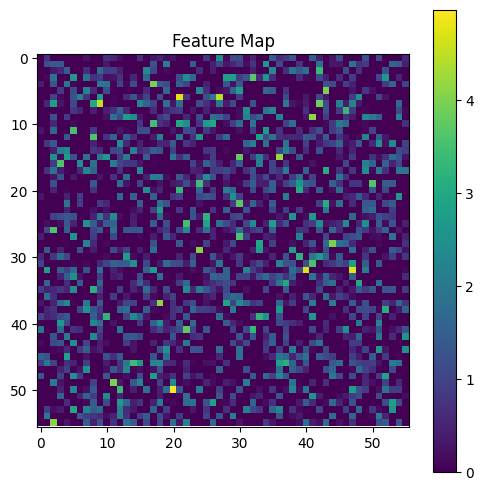

In [12]:
feature = out[0,0].detach().numpy()

plt.figure(figsize=(6,6))

plt.imshow(feature,cmap="viridis")

plt.title("Feature Map")

plt.colorbar()

plt.show()